# 🏏 IPL Data — Data Visualization
### CodeAlpha Data Analytics Internship — Task 3

**Dataset:** IPL Matches & Deliveries (2008–2022)  
**Tools Used:** Python, Pandas, Matplotlib, Seaborn  
**Author:** [Your Name Here]

---

### 📌 Objectives:
1. Transform raw IPL data into compelling visual stories
2. Design clear and impactful charts for decision-making
3. Reveal hidden patterns through advanced visualizations
4. Build a strong portfolio with well-designed, publication-ready plots

## 📦 Step 1: Import Libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Global styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


## 📂 Step 2: Load the Datasets

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
matches_path    = '/content/drive/MyDrive/Project/matches.csv'
deliveries_path = '/content/drive/MyDrive/Project/deliveries.csv'

In [21]:
matches    = pd.read_csv(matches_path)
deliveries = pd.read_csv(deliveries_path)

print(f'✅ matches.csv    loaded: {matches.shape[0]:,} rows × {matches.shape[1]} columns')
print(f'✅ deliveries.csv loaded: {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns')

✅ matches.csv    loaded: 636 rows × 18 columns
✅ deliveries.csv loaded: 179,078 rows × 21 columns


---
## 📊 VISUALIZATION 1: Top 10 Teams — Total Wins (Horizontal Bar Chart)

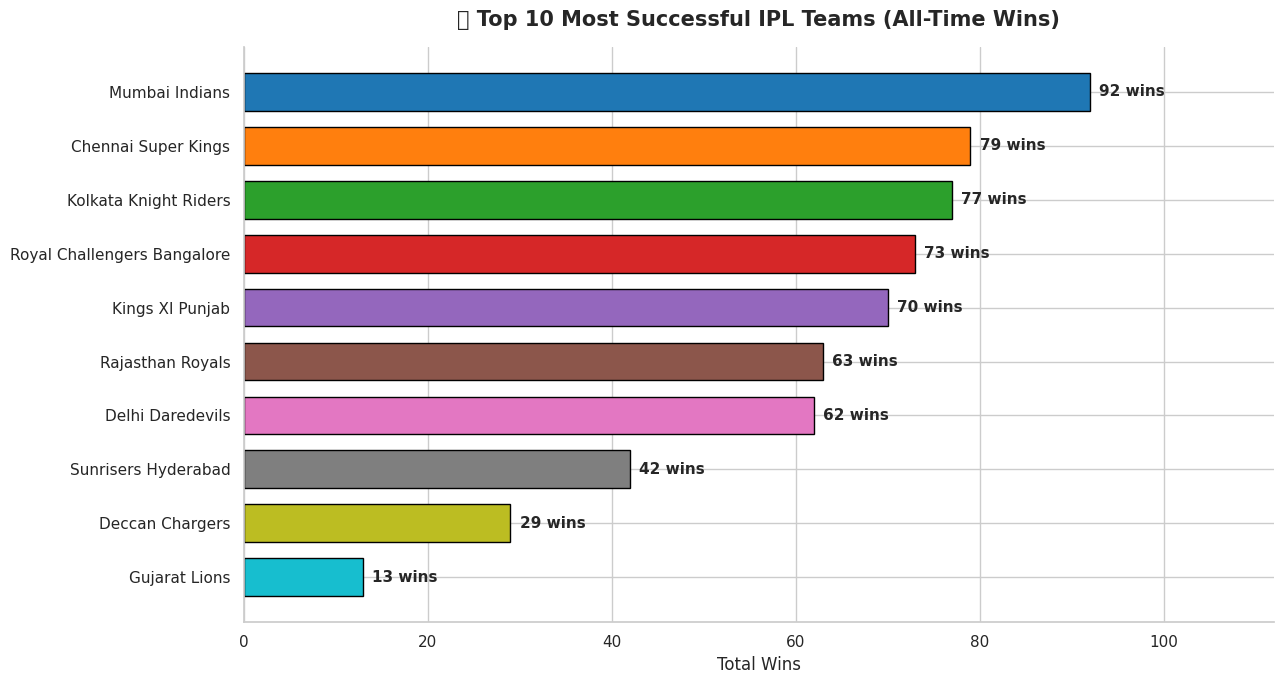

In [22]:
team_wins = matches['winner'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(13, 7))
colors = sns.color_palette('tab10', len(team_wins))
bars = ax.barh(team_wins.index[::-1], team_wins.values[::-1],
               color=colors[::-1], edgecolor='black', height=0.7)

for bar, val in zip(bars, team_wins.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val} wins', va='center', fontweight='bold', fontsize=11)

ax.set_title('🏆 Top 10 Most Successful IPL Teams (All-Time Wins)', pad=15)
ax.set_xlabel('Total Wins')
ax.set_xlim(0, team_wins.values.max() + 20)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('viz1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📈 VISUALIZATION 2: Season-wise Matches Trend (Line + Area Chart)

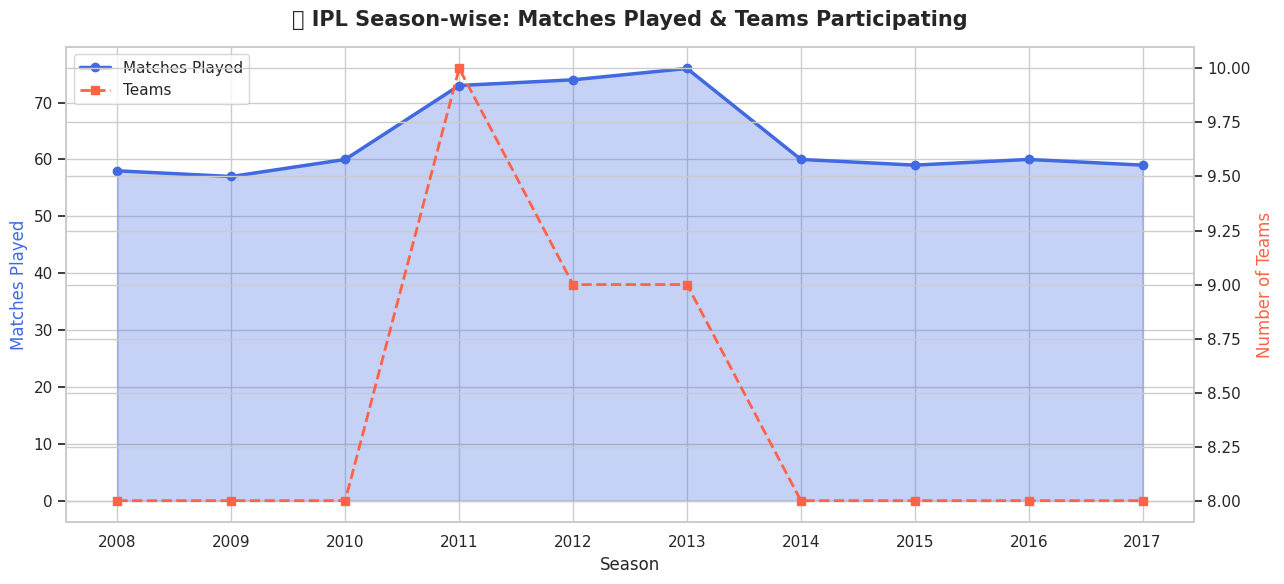

In [23]:
season_data = matches.groupby('season').agg(
    matches_played=('id', 'count'),
    unique_teams=('team1', lambda x: len(set(x) | set(matches.loc[x.index, 'team2'])))
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.fill_between(season_data['season'], season_data['matches_played'],
                 alpha=0.3, color='royalblue')
ax1.plot(season_data['season'], season_data['matches_played'],
         marker='o', color='royalblue', linewidth=2.5, label='Matches Played')
ax2.plot(season_data['season'], season_data['unique_teams'],
         marker='s', color='tomato', linewidth=2, linestyle='--', label='Teams')

ax1.set_title('📅 IPL Season-wise: Matches Played & Teams Participating', pad=15)
ax1.set_xlabel('Season')
ax1.set_ylabel('Matches Played', color='royalblue')
ax2.set_ylabel('Number of Teams', color='tomato')
ax1.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('viz2_season_trend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎲 VISUALIZATION 3: Toss Analysis — Decision & Impact (Pie + Grouped Bar)

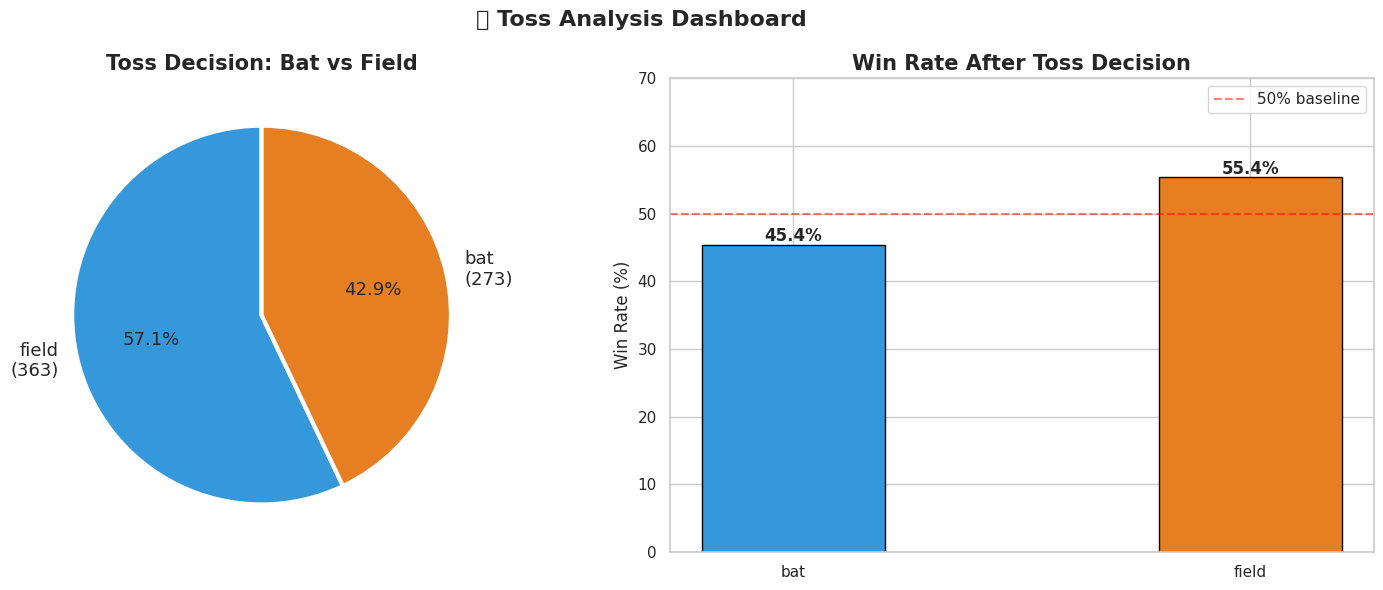

In [24]:
matches['toss_match_win'] = matches['toss_winner'] == matches['winner']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie — toss decision
toss_dec = matches['toss_decision'].value_counts()
axes[0].pie(toss_dec.values,
            labels=[f'{l}\n({v})' for l, v in zip(toss_dec.index, toss_dec.values)],
            autopct='%1.1f%%',
            colors=['#3498db', '#e67e22'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 3},
            textprops={'fontsize': 13})
axes[0].set_title('Toss Decision: Bat vs Field')

# Grouped bar — toss decision vs win rate
toss_win_rate = matches.groupby('toss_decision')['toss_match_win'].mean() * 100
bars = axes[1].bar(toss_win_rate.index, toss_win_rate.values,
                   color=['#3498db', '#e67e22'], edgecolor='black', width=0.4)
for bar, val in zip(bars, toss_win_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Win Rate After Toss Decision')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1].legend()

plt.suptitle('🎲 Toss Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏏 VISUALIZATION 4: Top 10 Batsmen — Runs + Strike Rate (Dual Axis)

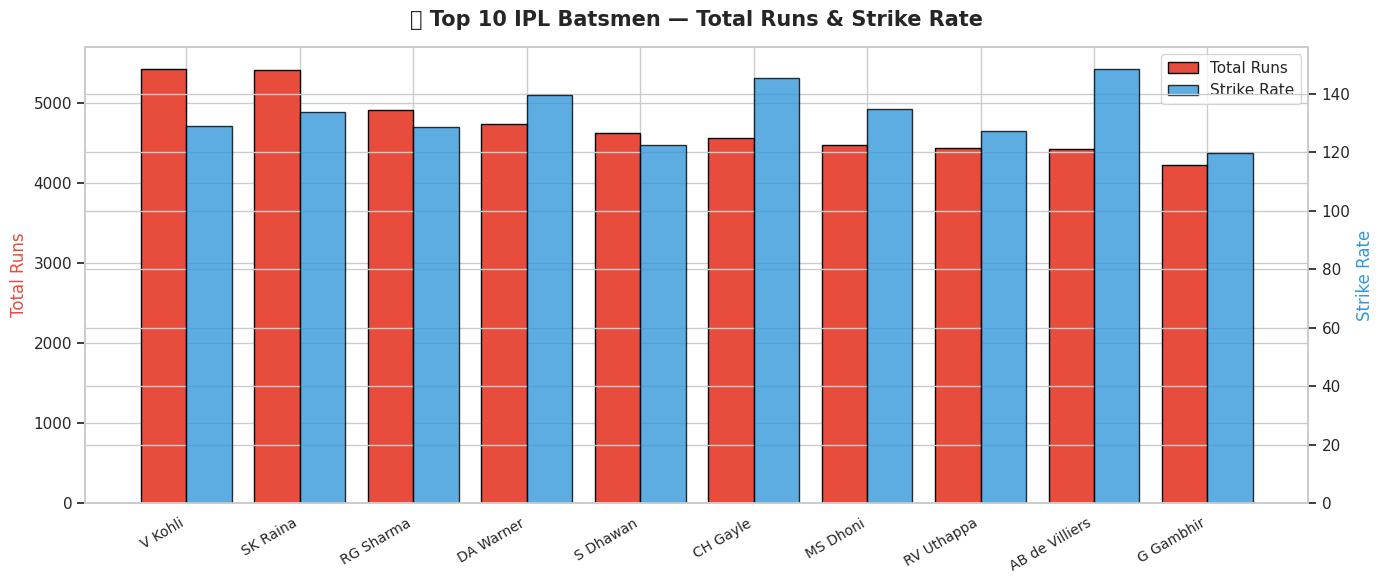

In [25]:
bat_stats = deliveries.groupby('batsman').agg(
    runs=('batsman_runs', 'sum'),
    balls=('ball', 'count')
).reset_index()
bat_stats['strike_rate'] = (bat_stats['runs'] / bat_stats['balls']) * 100
top10 = bat_stats.nlargest(10, 'runs').reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = np.arange(len(top10))
bars = ax1.bar(x - 0.2, top10['runs'], width=0.4,
               color='#e74c3c', edgecolor='black', label='Total Runs')
ax2.bar(x + 0.2, top10['strike_rate'], width=0.4,
        color='#3498db', edgecolor='black', alpha=0.8, label='Strike Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(top10['batsman'], rotation=30, ha='right', fontsize=10)
ax1.set_ylabel('Total Runs', color='#e74c3c', fontsize=12)
ax2.set_ylabel('Strike Rate', color='#3498db', fontsize=12)
ax1.set_title('🏏 Top 10 IPL Batsmen — Total Runs & Strike Rate', pad=15)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.savefig('viz4_top_batsmen.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎳 VISUALIZATION 5: Top 10 Bowlers — Wickets & Economy Rate

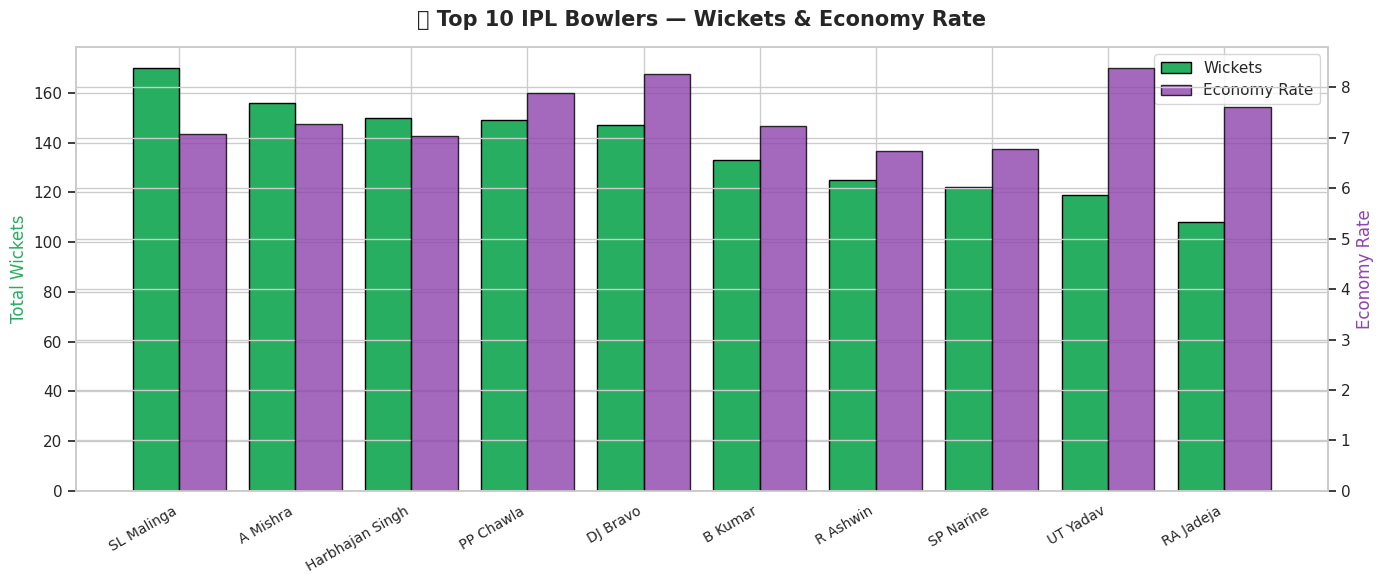

In [26]:
non_bowler = ['run out', 'retired hurt', 'obstructing the field']
wickets_df = deliveries[
    (deliveries['dismissal_kind'].notna()) &
    (~deliveries['dismissal_kind'].isin(non_bowler))
]
bowler_wkts = wickets_df.groupby('bowler')['dismissal_kind'].count()

bowler_runs = deliveries.groupby('bowler').agg(
    total_runs=('total_runs', 'sum'),
    overs=('ball', lambda x: len(x) / 6)
).reset_index()
bowler_runs['economy'] = bowler_runs['total_runs'] / bowler_runs['overs']

top10_bowl = bowler_wkts.nlargest(10).reset_index()
top10_bowl.columns = ['bowler', 'wickets']
top10_bowl = top10_bowl.merge(bowler_runs[['bowler', 'economy']], on='bowler')

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

x = np.arange(len(top10_bowl))
ax1.bar(x - 0.2, top10_bowl['wickets'], width=0.4,
        color='#27ae60', edgecolor='black', label='Wickets')
ax2.bar(x + 0.2, top10_bowl['economy'], width=0.4,
        color='#8e44ad', edgecolor='black', alpha=0.8, label='Economy Rate')

ax1.set_xticks(x)
ax1.set_xticklabels(top10_bowl['bowler'], rotation=30, ha='right', fontsize=10)
ax1.set_ylabel('Total Wickets', color='#27ae60', fontsize=12)
ax2.set_ylabel('Economy Rate', color='#8e44ad', fontsize=12)
ax1.set_title('🎳 Top 10 IPL Bowlers — Wickets & Economy Rate', pad=15)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right')
plt.tight_layout()
plt.savefig('viz5_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔥 VISUALIZATION 6: Runs Per Over Heatmap (Over × Inning)

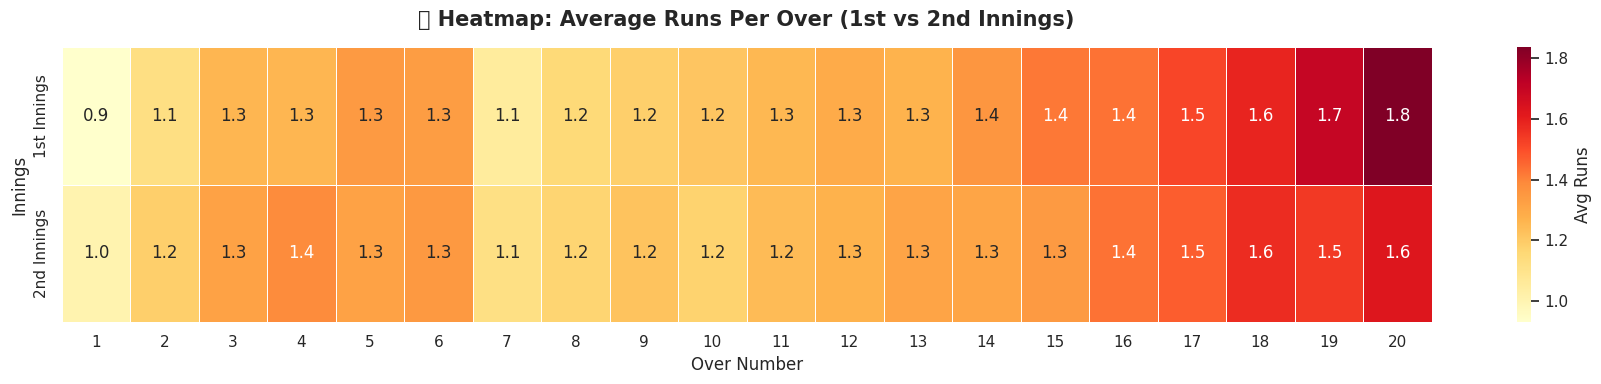

In [27]:
heatmap_data = deliveries.groupby(['inning', 'over'])['total_runs'].mean().unstack()
heatmap_data = heatmap_data[heatmap_data.index.isin([1, 2])]  # only 1st & 2nd innings

plt.figure(figsize=(18, 4))
sns.heatmap(heatmap_data,
            cmap='YlOrRd',
            annot=True, fmt='.1f',
            linewidths=0.4,
            cbar_kws={'label': 'Avg Runs'},
            yticklabels=['1st Innings', '2nd Innings'])
plt.title('🔥 Heatmap: Average Runs Per Over (1st vs 2nd Innings)', pad=15)
plt.xlabel('Over Number')
plt.ylabel('Innings')
plt.tight_layout()
plt.savefig('viz6_heatmap_runs.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📦 VISUALIZATION 7: Run Distribution — Top 6 Teams (Box Plot)

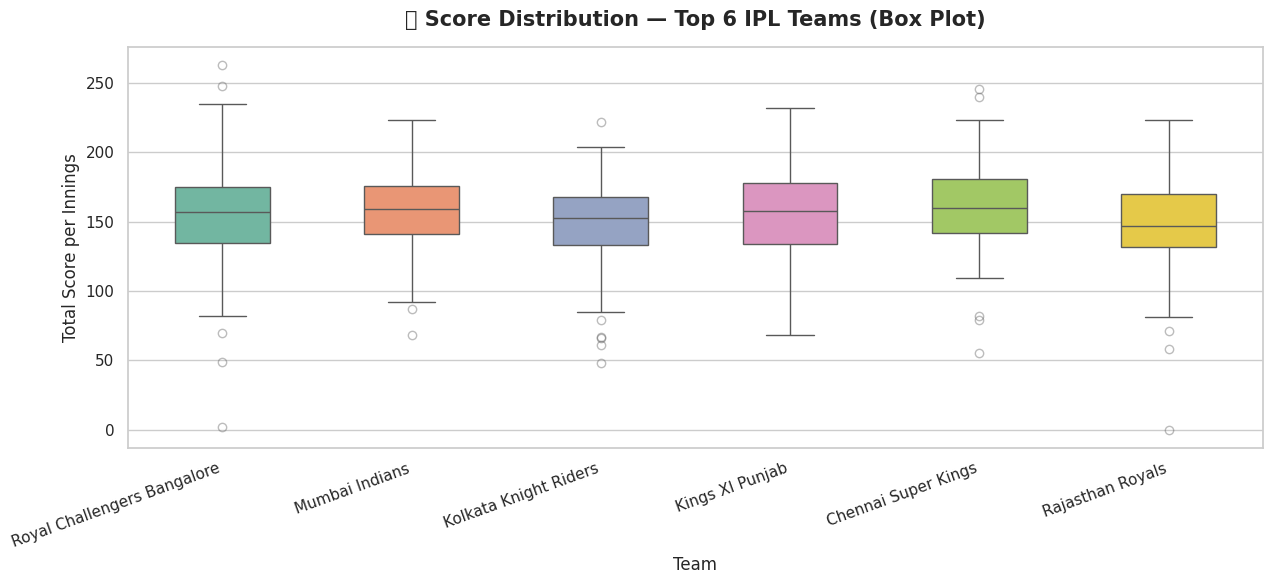

In [28]:
top6_teams = matches['winner'].value_counts().head(6).index.tolist()

team_scores = []
for _, row in matches.iterrows():
    match_del = deliveries[deliveries['match_id'] == row['id']]
    for team in [row['team1'], row['team2']]:
        if team in top6_teams:
            score = match_del[match_del['batting_team'] == team]['total_runs'].sum()
            team_scores.append({'team': team, 'score': score})

scores_df = pd.DataFrame(team_scores)

plt.figure(figsize=(13, 6))
sns.boxplot(data=scores_df, x='team', y='score',
            palette='Set2', width=0.5,
            flierprops=dict(marker='o', color='red', alpha=0.4))
plt.title('📦 Score Distribution — Top 6 IPL Teams (Box Plot)', pad=15)
plt.xlabel('Team')
plt.ylabel('Total Score per Innings')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('viz7_boxplot_scores.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🍩 VISUALIZATION 8: Dismissal Types Distribution (Donut Chart)

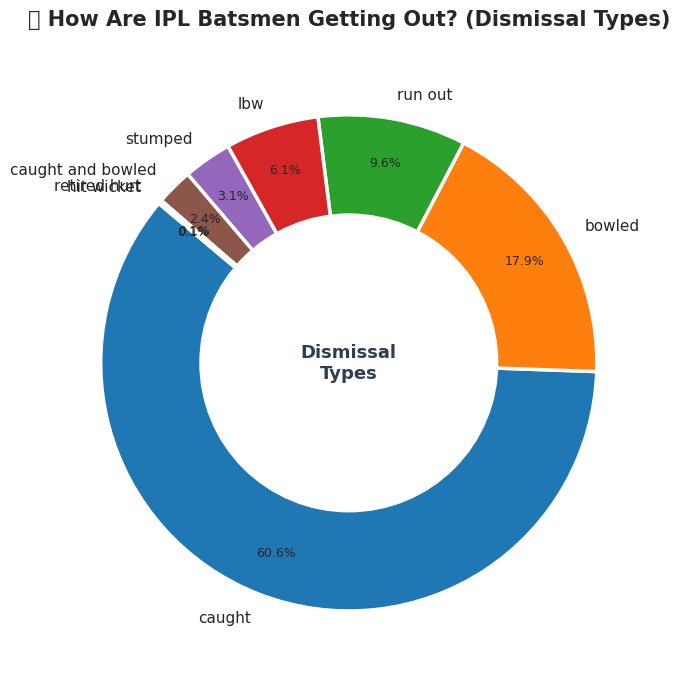

In [29]:
dismissal_counts = deliveries['dismissal_kind'].value_counts().dropna().head(8)

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    dismissal_counts.values,
    labels=dismissal_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.82,
    colors=sns.color_palette('tab10', len(dismissal_counts)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5}
)
# Make donut
centre_circle = plt.Circle((0, 0), 0.60, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, 'Dismissal\nTypes', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2c3e50')

for autotext in autotexts:
    autotext.set_fontsize(9)

ax.set_title('🍩 How Are IPL Batsmen Getting Out? (Dismissal Types)', pad=20)
plt.tight_layout()
plt.savefig('viz8_dismissal_donut.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🏟️ VISUALIZATION 9: Top Venues — Matches Hosted (Bubble Chart)

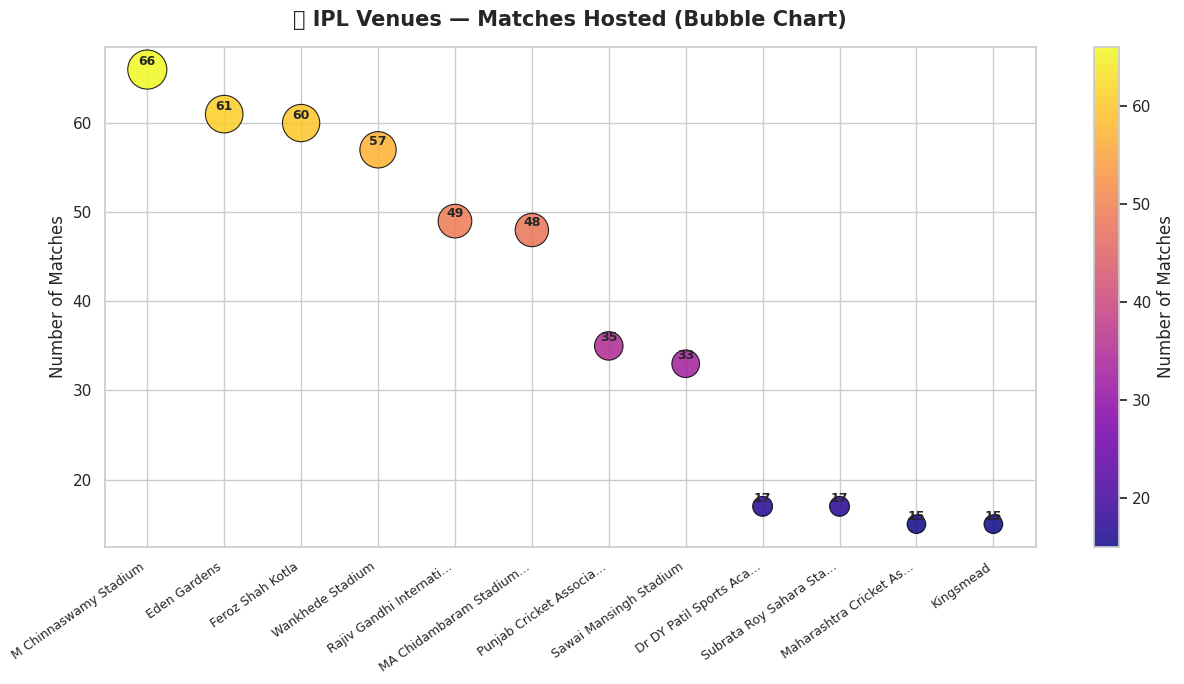

In [30]:
venue_data = matches['venue'].value_counts().head(12).reset_index()
venue_data.columns = ['venue', 'matches']
venue_data['short'] = venue_data['venue'].apply(lambda x: x[:22] + '...' if len(x) > 22 else x)

plt.figure(figsize=(13, 7))
scatter = plt.scatter(
    range(len(venue_data)),
    venue_data['matches'],
    s=venue_data['matches'] * 12,
    c=venue_data['matches'],
    cmap='plasma',
    alpha=0.85,
    edgecolors='black',
    linewidths=0.8
)
plt.colorbar(scatter, label='Number of Matches')
plt.xticks(range(len(venue_data)), venue_data['short'], rotation=35, ha='right', fontsize=9)
plt.ylabel('Number of Matches')
plt.title('🏟️ IPL Venues — Matches Hosted (Bubble Chart)', pad=15)
for i, row in venue_data.iterrows():
    plt.text(i, row['matches'] + 0.5, str(row['matches']),
             ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('viz9_venue_bubble.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 VISUALIZATION 10: Final Dashboard — 4-in-1 Summary Chart

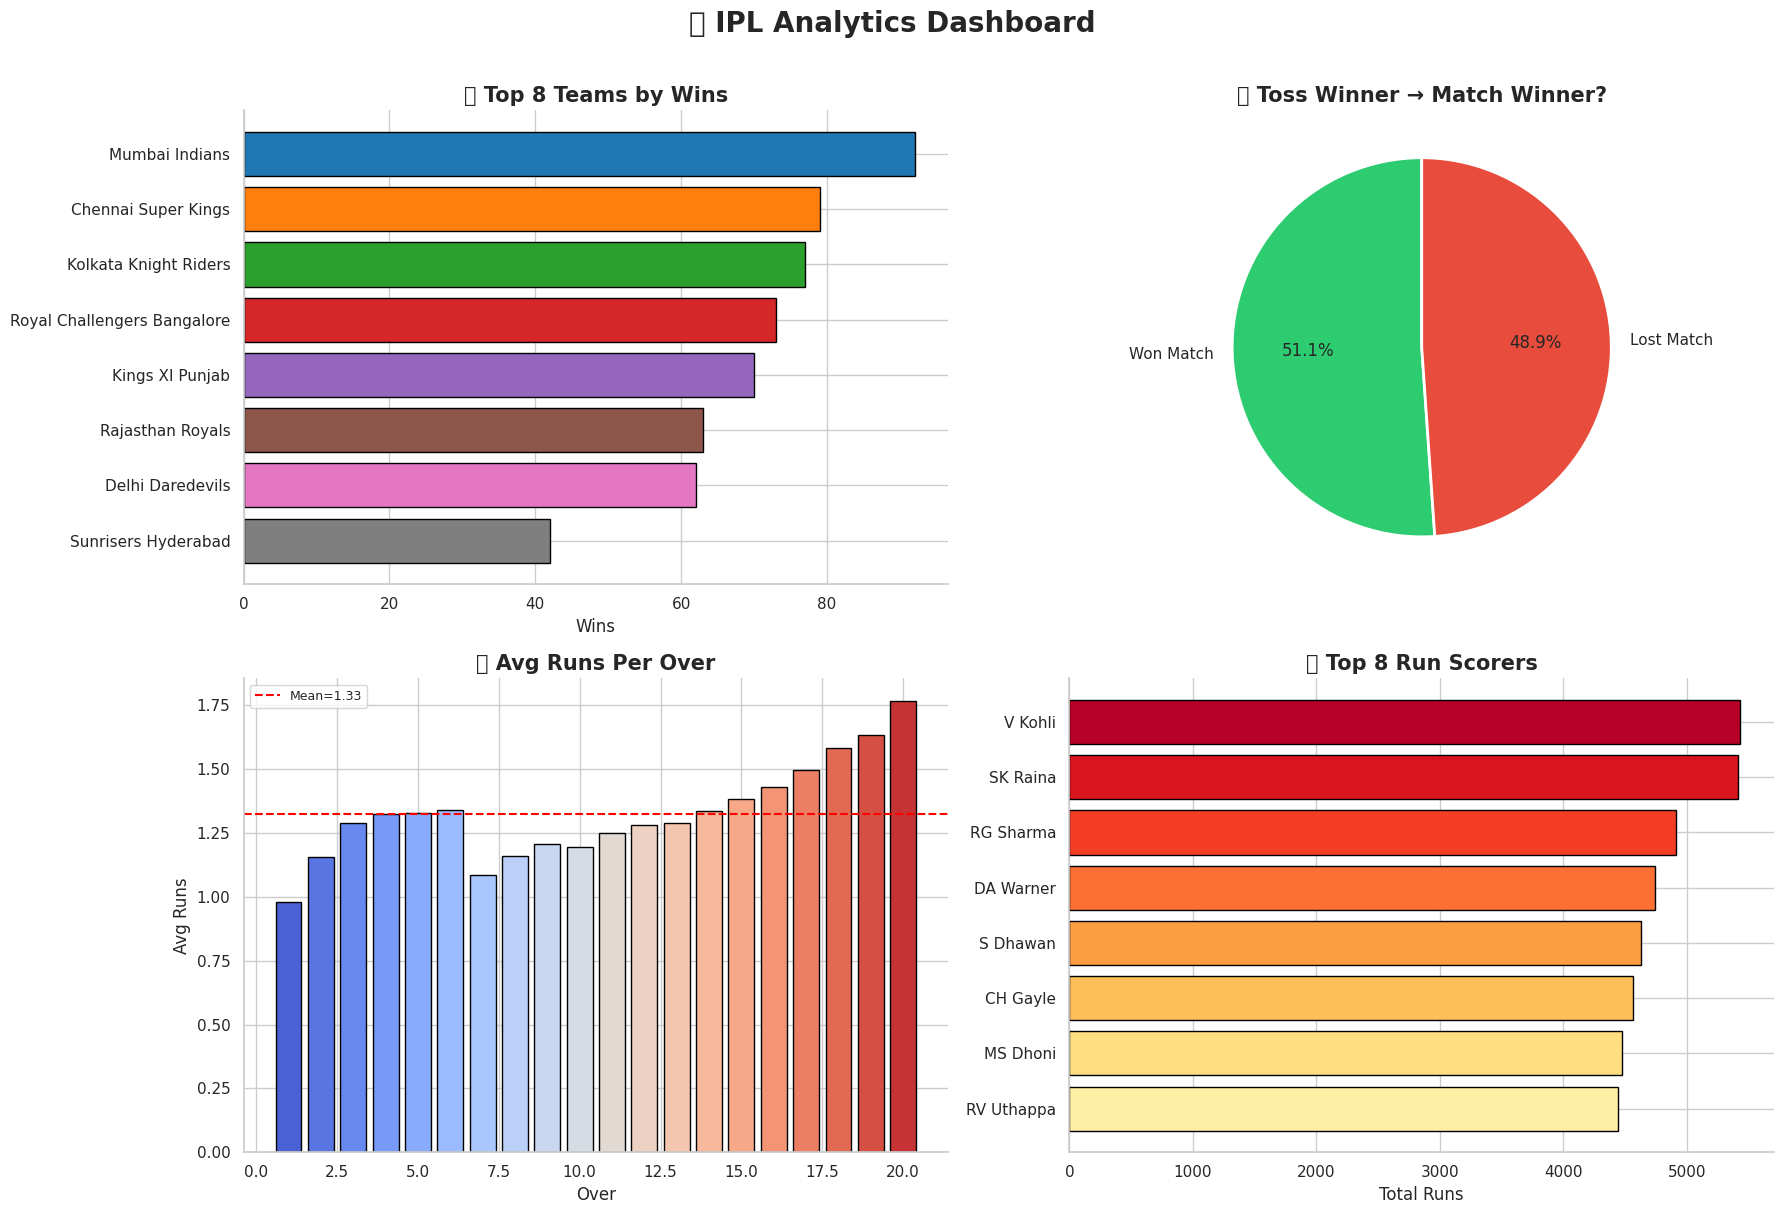

✅ All 10 Visualizations Complete! Charts saved as PNG files.


In [32]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('🏏 IPL Analytics Dashboard', fontsize=20, fontweight='bold', y=1.01)

# ── Panel 1: Team wins ──────────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
tw = matches['winner'].value_counts().head(8)
ax1.barh(tw.index[::-1], tw.values[::-1],
         color=sns.color_palette('tab10', 8)[::-1], edgecolor='black')
ax1.set_title('🏆 Top 8 Teams by Wins')
ax1.set_xlabel('Wins')
ax1.spines[['top', 'right']].set_visible(False)

# ── Panel 2: Toss impact pie ────────────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
toss_result = matches['toss_match_win'].value_counts()
ax2.pie(toss_result.values,
        labels=['Won Match', 'Lost Match'],
        autopct='%1.1f%%',
        colors=['#2ecc71', '#e74c3c'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('🎲 Toss Winner → Match Winner?')

# ── Panel 3: Runs per over ──────────────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
over_runs = deliveries.groupby('over')['total_runs'].mean()
ax3.bar(over_runs.index, over_runs.values,
        color=sns.color_palette('coolwarm', len(over_runs)), edgecolor='black')
ax3.axhline(over_runs.mean(), color='red', linestyle='--',
            label=f'Mean={over_runs.mean():.2f}')
ax3.set_title('📊 Avg Runs Per Over')
ax3.set_xlabel('Over')
ax3.set_ylabel('Avg Runs')
ax3.legend(fontsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# ── Panel 4: Top batsmen ────────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
tb = deliveries.groupby('batsman')['batsman_runs'].sum().nlargest(8)
ax4.barh(tb.index[::-1], tb.values[::-1],
         color=sns.color_palette('YlOrRd_r', 8)[::-1], edgecolor='black')
ax4.set_title('🏏 Top 8 Run Scorers')
ax4.set_xlabel('Total Runs')
ax4.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('viz10_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ All 10 Visualizations Complete! Charts saved as PNG files.')

---
## 📋 Summary of Visualizations

| # | Chart Type | Topic |
|---|-----------|-------|
| 1 | Horizontal Bar | Top 10 Teams by Wins |
| 2 | Line + Area (Dual Axis) | Season-wise Matches & Teams |
| 3 | Pie + Bar | Toss Decision & Win Impact |
| 4 | Grouped Bar (Dual Axis) | Top Batsmen — Runs & Strike Rate |
| 5 | Grouped Bar (Dual Axis) | Top Bowlers — Wickets & Economy |
| 6 | Heatmap | Runs Per Over (1st vs 2nd Innings) |
| 7 | Box Plot | Score Distribution — Top 6 Teams |
| 8 | Donut Chart | Dismissal Types |
| 9 | Bubble Chart | Venues by Matches Hosted |
| 10 | 4-in-1 Dashboard | Full IPL Summary |

---
